<a href="https://colab.research.google.com/github/kevinketerlondon-tech/Data-Analyst-portfolio/blob/main/week_3_12_KevinKeter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

In [ ]:
spark = SparkSession.builder \
                    .appName("PropertyLinearRegression_spark") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()


In [ ]:
print(f"Spark UI available at: {spark.sparkContext.uiWebUrl}")

Spark UI available at: http://61c2c738dc72:4040


In [ ]:
spark.sparkContext.setLogLevel("INFO")

In [ ]:
import psutil
print(f"CPU Usage: {psutil.cpu_percent()}%")
print(f"Memory Usage: {psutil.virtual_memory().percent}%")

CPU Usage: 80.8%
Memory Usage: 12.1%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = spark.read.csv("/content/drive/MyDrive/property (2).csv", header=True, inferSchema=True)

In [ ]:
df.show()
print("Total Records",df.count())
print("Total Partitions ",df.rdd.getNumPartitions())

+--------------+------------+-------------+----------+--------+------------------+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|             Price|
+--------------+------------+-------------+----------+--------+------------------+
|          1360|           2|            3|      1953|    7860| 303948.1373854071|
|          4272|           3|            3|      1997|    5292| 860386.2685075302|
|          3592|           4|            1|      1983|    9723| 734389.7538956215|
|           966|           6|            1|      1903|    4086| 226448.8070714377|
|          4926|           6|            4|      1944|    1081|1022486.2616704078|
|          3944|           6|            2|      1938|    3542| 845638.1354384426|
|          3671|           2|            1|      1963|    5105| 748779.2192281872|
|          3419|           4|            2|      1925|    5448| 743007.2614135538|
|           630|           2|            2|      2012|    3204| 135656.4528785377|
|   

In [ ]:
df.printSchema()

root
 |-- Square_Footage: integer (nullable = true)
 |-- Num_Bedrooms: integer (nullable = true)
 |-- Num_Bathrooms: integer (nullable = true)
 |-- Year_Built: integer (nullable = true)
 |-- Lot_Size: integer (nullable = true)
 |-- Price: double (nullable = true)



In [ ]:
df.describe().show()

+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|summary|   Square_Footage|     Num_Bedrooms|     Num_Bathrooms|       Year_Built|         Lot_Size|             Price|
+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|  count|          1000000|          1000000|           1000000|          1000000|          1000000|           1000000|
|   mean|      2750.657104|         3.501114|          2.500439|       1960.52736|      5502.373911| 581839.6653163614|
| stddev|1298.569362387213|1.708173784151257|1.1178528780094728|35.21780350510348|2598.885882999355|260685.36722644986|
|    min|              500|                1|                 1|             1900|             1000| 51495.71116919513|
|    max|             4999|                6|                 4|             2021|             9999|1123219.4691521737|
+-------+-----------------+-------------

In [ ]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 32.6%
Memory Usage after csv file: 16.3%


In [ ]:
from pyspark.sql.functions import col,isnan, when, count
df.select([count(when(isnan(c) | col(c).isNull(), c))
.alias(c) for c in df.columns]).show()

+--------------+------------+-------------+----------+--------+-----+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|Price|
+--------------+------------+-------------+----------+--------+-----+
|             0|           0|            0|         0|       0|    0|
+--------------+------------+-------------+----------+--------+-----+



In [ ]:
from pyspark.ml.feature import StringIndexer
indexer = StringIndexer(inputCol = 'Num_Bedrooms', outputCol = 'Room')
df = indexer.fit(df).transform(df)
df.show()

+--------------+------------+-------------+----------+--------+------------------+----+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|             Price|Room|
+--------------+------------+-------------+----------+--------+------------------+----+
|          1360|           2|            3|      1953|    7860| 303948.1373854071| 1.0|
|          4272|           3|            3|      1997|    5292| 860386.2685075302| 3.0|
|          3592|           4|            1|      1983|    9723| 734389.7538956215| 2.0|
|           966|           6|            1|      1903|    4086| 226448.8070714377| 0.0|
|          4926|           6|            4|      1944|    1081|1022486.2616704078| 0.0|
|          3944|           6|            2|      1938|    3542| 845638.1354384426| 0.0|
|          3671|           2|            1|      1963|    5105| 748779.2192281872| 1.0|
|          3419|           4|            2|      1925|    5448| 743007.2614135538| 2.0|
|           630|           2|   

In [ ]:
df = spark.read.csv("/content/drive/MyDrive/property (2).csv", header=True, inferSchema=True)
from pyspark.ml.feature import StringIndexer
indexer = StringIndexer(inputCol = 'Num_Bedrooms', outputCol = 'Room')
df = indexer.fit(df).transform(df)

from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler( inputCols=["Square_Footage", "Num_Bedrooms", "Year_Built", "Lot_Size", "Room"],
 outputCol="Features" )
df = assembler.transform(df)
df.show()

+--------------+------------+-------------+----------+--------+------------------+----+--------------------+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|             Price|Room|            Features|
+--------------+------------+-------------+----------+--------+------------------+----+--------------------+
|          1360|           2|            3|      1953|    7860| 303948.1373854071| 1.0|[1360.0,2.0,1953....|
|          4272|           3|            3|      1997|    5292| 860386.2685075302| 3.0|[4272.0,3.0,1997....|
|          3592|           4|            1|      1983|    9723| 734389.7538956215| 2.0|[3592.0,4.0,1983....|
|           966|           6|            1|      1903|    4086| 226448.8070714377| 0.0|[966.0,6.0,1903.0...|
|          4926|           6|            4|      1944|    1081|1022486.2616704078| 0.0|[4926.0,6.0,1944....|
|          3944|           6|            2|      1938|    3542| 845638.1354384426| 0.0|[3944.0,6.0,1938....|
|          3671|   

In [ ]:
scaler = StandardScaler(inputCol = "Features",
                        outputCol = "scaled_Features")

In [ ]:
regressor = LinearRegression(labelCol = 'Price',
                             featuresCol = 'scaled_Features'
                             )

In [ ]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 98.7%
Memory Usage after csv file: 17.0%


In [ ]:
from pyspark.ml import Pipeline
pipeline  = Pipeline(stages = [indexer,assembler,scaler,regressor])
pipeline.write().overwrite().save("pipeline_LRsaved_model")

In [ ]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 98.3%
Memory Usage after csv file: 17.1%


In [ ]:
pipelineModel = Pipeline.load('./pipeline_LRsaved_model')

In [ ]:
data_train , data_test = df.randomSplit([0.7,0.3], seed = 123)

In [ ]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 95.3%
Memory Usage after csv file: 17.2%


In [ ]:
from pyspark.ml import Pipeline

temp_pipeline = Pipeline(stages=[scaler, regressor])

Model = temp_pipeline.fit(data_train)

In [ ]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 99.4%
Memory Usage after csv file: 21.0%


In [ ]:
print("total LR cofficents",len(Model.stages[1].coefficients) )
print("Cofficientents",Model.stages[1].coefficients)
print("Intecept",Model.stages[1].intercept)

total LR cofficents 5
Cofficientents [259718.3023689416,8484.83924088861,-3515.5811689825605,257.25730792826806,-2.2902090821198784]
Intecept 209419.97229363106


In [ ]:
pred = Model.transform(data_test)
pred.select('prediction', 'Price').show(10, truncate = False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|122654.46267808152|117632.63219959654|
|114347.53488705387|106670.25438504865|
|125119.19755008453|117919.45375887671|
|114320.05506052205|119893.50473253023|
|112935.23505454246|115218.14440379351|
|121269.56717836477|142918.60554292126|
|126301.9617582436 |95443.54011673816 |
|119435.91990395394|75029.23686169085 |
|126037.44664981411|128827.18170769783|
|126125.19515045304|131723.44904010184|
+------------------+------------------+
only showing top 10 rows


In [ ]:
Lasoregressor = LinearRegression(labelCol = 'Price',
                             featuresCol = 'scaled_Features',
                             elasticNetParam=1,
                             regParam=0.1
                             )
Lasaopipeline  = Pipeline(stages = [scaler,Lasoregressor])
LassoModel = Lasaopipeline.fit(data_train)

In [ ]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 91.7%
Memory Usage after csv file: 21.1%


In [ ]:
lassopred = LassoModel.transform(data_test)
lassopred.select('prediction', 'Price').show(10, truncate = False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|122654.81438127154|117632.63219959654|
|114348.09578064519|106670.25438504865|
|125119.24006826422|117919.45375887671|
|114320.51948700011|119893.50473253023|
|112935.91293634604|115218.14440379351|
|121269.81113432853|142918.60554292126|
|126301.92498344596|95443.54011673816 |
|119436.28552578522|75029.23686169085 |
|126037.51200583205|128827.18170769783|
|126125.2980110889 |131723.44904010184|
+------------------+------------------+
only showing top 10 rows


In [ ]:
Ridgeregressor = LinearRegression(labelCol = 'Price',
                             featuresCol = 'scaled_Features',
                             elasticNetParam=0,
                             regParam=0.1
                             )
Ridgepipeline  = Pipeline(stages = [scaler,Ridgeregressor])
RidgeModel = Ridgepipeline.fit(data_train)

In [ ]:
Ridgepred = RidgeModel.transform(data_test)
Ridgepred.select('prediction', 'Price').show(10, truncate = False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|122654.63781788148|117632.63219959654|
|114347.71347613439|106670.25438504865|
|125119.37242912636|117919.45375887671|
|114320.2339608739 |119893.50473253023|
|112935.4139787574 |115218.14440379351|
|121269.7433333881 |142918.60554292126|
|126302.13774612051|95443.54011673816 |
|119436.09803453655|75029.23686169085 |
|126037.62245287886|128827.18170769783|
|126125.37079451213|131723.44904010184|
+------------------+------------------+
only showing top 10 rows


In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator
evaluator_mse = RegressionEvaluator(labelCol =
                                    'Price',
                                    predictionCol =
                                    'prediction',
                                    metricName =
                                    'mse')

mse1 = evaluator_mse.evaluate(pred)
mselasso = evaluator_mse.evaluate(lassopred)
mseridge = evaluator_mse.evaluate(Ridgepred)

evaluator_rmse = RegressionEvaluator(labelCol =
                                     'Price',
                                     predictionCol =
                                     'prediction',
                                     metricName =
                                     'rmse')

rmse1 = evaluator_rmse.evaluate(pred)
rmse2_lasso = evaluator_rmse.evaluate(lassopred)
rmse3Ridge = evaluator_rmse.evaluate(Ridgepred)

evaluator_r2 = RegressionEvaluator(labelCol = 'Price',
                                   predictionCol = 'prediction',
                                   metricName = 'r2')

r2_score1 = evaluator_r2.evaluate(pred)
r2_lasso = evaluator_r2.evaluate(lassopred)
r2_ridge = evaluator_r2.evaluate(Ridgepred)
print('Regression - MSE: ', mse1, ', RMSE: ', rmse1, ', R^2: ', r2_score1)
print('Lasso - MSE: ', mselasso, ', RMSE: ', rmse2_lasso, ', R^2: ', r2_lasso)
print('Ridge - MSE: ', mseridge, ', RMSE: ', rmse3Ridge, ', R^2: ', r2_ridge)

Regression - MSE:  409235620.5833089 , RMSE:  20229.572921426414 , R^2:  0.993978724379986
Lasso - MSE:  409235656.2861617 , RMSE:  20229.573803868476 , R^2:  0.9939787238546732
Ridge - MSE:  409235619.97697514 , RMSE:  20229.572906440095 , R^2:  0.9939787243889073


In [ ]:
feature_sets = [
    ["Square_Footage", "Num_Bedrooms"],
    ["Square_Footage", "Num_Bathrooms", "Lot_Size"],
    ["Square_Footage", "Num_Bedrooms", "Year_Built", "Lot_Size"],
    ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "Year_Built", "Lot_Size"]
]

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

results = []

for i, features in enumerate(feature_sets):

    output_feature_col = f"Features_set_{i}"
    assembler = VectorAssembler(inputCols=features, outputCol=output_feature_col)


    df_for_assembly = df.select(*features, "Price")

    df_assembled = assembler.transform(df_for_assembly)

    lr = LinearRegression(featuresCol=output_feature_col, labelCol="Price")
    model = lr.fit(df_assembled)

    r2 = model.summary.r2
    results.append((features, r2))

for features, r2 in results:
    print(f"Features: {features} → R² = {r2}")

Features: ['Square_Footage', 'Num_Bedrooms'] → R² = 0.9937691078487031
Features: ['Square_Footage', 'Num_Bathrooms', 'Lot_Size'] → R² = 0.9928723448464285
Features: ['Square_Footage', 'Num_Bedrooms', 'Year_Built', 'Lot_Size'] → R² = 0.9939532453915436
Features: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size'] → R² = 0.9941210330472702


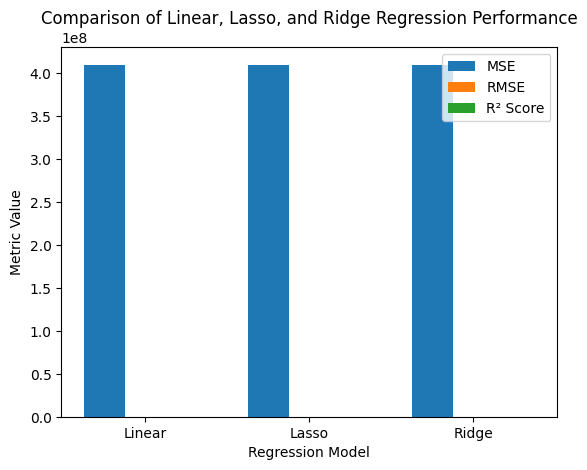

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
mse = [mse1, mselasso, mseridge]
rmse = [rmse1, rmse2_lasso, rmse3Ridge]
r2_score = [r2_score1, r2_lasso, r2_ridge]
positions = np.arange(len(mse))
bar_width = 0.25
plt.bar(positions - bar_width, mse, width=bar_width, label='MSE')
plt.bar(positions, rmse, width=bar_width, label='RMSE')
plt.bar(positions + bar_width, r2_score, width=bar_width, label='R² Score')
plt.xlabel('Regression Model')
plt.ylabel('Metric Value')
plt.title('Comparison of Linear, Lasso, and Ridge Regression Performance')
plt.xticks(positions, ['Linear', 'Lasso', 'Ridge'])
plt.legend()
plt.show()


In this exercise, I explored multiple linear regression techniques to understand how different modelling choices and feature combinations influence predictive performance. My primary goal was to evaluate how well various regression models could predict housing prices using a selection of numerical features. I implemented three models: standard Linear Regression, Lasso Regression, and Ridge Regression. Each model used the same set of scaled features, allowing me to compare the effect of regularisation rather than feature changes.

In this exercise, I explored multiple linear regression techniques to understand how different modelling choices and feature combinations influence predictive performance. My primary goal was to evaluate how well various regression models could predict housing prices using a selection of numerical features. I implemented three models: standard Linear Regression, Lasso Regression, and Ridge Regression. Each model used the same set of scaled features, allowing me to compare the effect of regularisation rather than feature changes.

For my feature selection, I focused on numerical variables such as Square_Footage, Num_Bedrooms, Num_Bathrooms, Year_Built, Lot_Size, and Room. These are all factors that typically influence how a property is valued, so they made sense as inputs for predicting house prices. I made sure not to include the target variable Price in the feature set, since that would leak the answer into the model and give unrealistic results. I also applied feature scaling before training the models. This step is especially important for Lasso and Ridge regression because their regularisation methods are sensitive to the scale of the input features, and scaling helps the models treat each variable fairly

When looking at the chart, it may seem as though only the MSE bars are visible, while the RMSE and R² bars barely show up. This isn’t a mistake in the plotting  it’s simply a result of the scale of the values. MSE tends to be extremely large because it squares the prediction errors, which pushes the numbers into the hundreds of millions. RMSE, on the other hand, is much smaller since it is the square root of MSE, and R² is even smaller because it always falls between 0 and 1. When all three metrics are displayed on the same graph, the huge difference in magnitude causes the RMSE and R² bars to appear almost flat next to the MSE bars. The chart is still accurate, but it highlights how differently these metrics behave and why their numerical values need to be interpreted directly rather than relying solely on the visual height of the bars.

Challenges and How I Resolved Them
One of the main challenges I encountered was understanding the correct separation between independent and dependent variables. Initially, I mistakenly included the target variable Price inside the feature vector, which caused confusion and incorrect model behaviour. After revisiting the VectorAssembler logic, I corrected this by ensuring that only independent variables were included in the Features column.

This exercise helped me understand the importance of proper feature engineering and model evaluation. I learned how regularisation techniques like Lasso and Ridge can influence model complexity and prevent overfitting. I also gained practical experience in comparing models using quantitative metrics and visualisation. Most importantly, I developed a clearer understanding of how Spark’s machine learning pipeline works, particularly the role of the VectorAssembler and the need for consistent feature preprocessing













